# Traffic Flow Pattern Analysis — Exploratory Data Analysis (EDA)

**Student Name:** k.satya charan

## Objective
Perform Exploratory Data Analysis on the traffic-flow dataset to understand traffic patterns, distributions, relationships, congestion levels, time-based behavior, and possible outliers.

**Note:** This notebook is **EDA only**. No machine-learning model or clustering algorithm is used.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the Traffic Dataset

In [2]:
DATA_PATH = r"C:\Users\satya\Downloads\traffic_flow_pattern_clustering_kmeans_dbscan\traffic_congestion_project\data\traffic_flow_6000.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (6000, 21)


,timestamp,route_id,origin,destination,distance_km,road_type,lanes,speed_limit_kmh,vehicle_count,avg_speed_kmh,...,rainfall_mm,temperature_c,incident_level,holiday,event_score,travel_time_min,congestion_level,day_of_week,hour,is_weekend
0,2025-02-02T14:40,R01,Bachupally,HITEC City,18.0,Urban Arterial,3,50,93,40.54,...,0.00,28.51,0,0,1,38.43,Low,6,14,1
1,2025-05-27T14:40,R02,Bachupally,HITEC City,20.5,Ring Road,4,60,116,28.84,...,3.08,27.80,1,0,0,44.31,High,1,14,0
2,2025-05-13T03:20,R03,Bachupally,HITEC City,17.2,Expressway,4,70,138,44.60,...,0.00,22.95,0,0,1,33.61,Medium,1,3,0
3,2025-07-26T14:40,R04,Kukatpally,HITEC City,12.6,Urban Arterial,3,50,91,36.61,...,0.00,28.93,0,0,1,29.79,Low,5,14,1
4,2025-10-18T18:40,R05,Kukatpally,HITEC City,14.0,Ring Road,4,60,188,30.78,...,0.00,26.90,0,0,1,32.01,High,5,18,1


## 3. Understand the Dataset

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Number of rows: 6000
Number of columns: 21

Column names:
['timestamp', 'route_id', 'origin', 'destination', 'distance_km', 'road_type', 'lanes', 'speed_limit_kmh', 'vehicle_count', 'avg_speed_kmh', 'occupancy_pct', 'rainfall_mm', 'temperature_c', 'incident_level', 'holiday', 'event_score', 'travel_time_min', 'congestion_level', 'day_of_week', 'hour', 'is_weekend']

Data types:
timestamp               str
route_id                str
origin                  str
destination             str
distance_km         float64
road_type               str
lanes                 int64
speed_limit_kmh       int64
vehicle_count         int64
avg_speed_kmh       float64
occupancy_pct       float64
rainfall_mm         float64
temperature_c       float64
incident_level        int64
holiday               int64
event_score           int64
travel_time_min     float64
congestion_level        str
day_of_week           int64
hour                  int64
is_weekend            int64
dtype: object


In [4]:
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         6000 non-null   str    
 1   route_id          6000 non-null   str    
 2   origin            6000 non-null   str    
 3   destination       6000 non-null   str    
 4   distance_km       6000 non-null   float64
 5   road_type         6000 non-null   str    
 6   lanes             6000 non-null   int64  
 7   speed_limit_kmh   6000 non-null   int64  
 8   vehicle_count     6000 non-null   int64  
 9   avg_speed_kmh     6000 non-null   float64
 10  occupancy_pct     6000 non-null   float64
 11  rainfall_mm       6000 non-null   float64
 12  temperature_c     6000 non-null   float64
 13  incident_level    6000 non-null   int64  
 14  holiday           6000 non-null   int64  
 15  event_score       6000 non-null   int64  
 16  travel_time_min   6000 non-null 

In [5]:
print("Statistical summary:")
df.describe(include="all").T


Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,6000,5569,2025-05-10T15:30,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route_id,6000,15,R01,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin,6000,10,Bachupally,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination,6000,6,HITEC City,3200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,6000.0,NaN,NaN,NaN,15.64,4.680105,8.4,10.5,16.8,19.5,24.0
road_type,6000,3,Urban Arterial,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lanes,6000.0,NaN,NaN,NaN,3.533333,0.498929,3.0,3.0,4.0,4.0,4.0
speed_limit_kmh,6000.0,NaN,NaN,NaN,56.666667,6.992642,50.0,50.0,60.0,60.0,70.0
vehicle_count,6000.0,NaN,NaN,NaN,138.675667,42.742718,80.0,105.0,133.0,167.0,302.0
avg_speed_kmh,6000.0,NaN,NaN,NaN,34.628393,8.019668,10.22,28.94,34.16,39.7725,65.53


## 4. Check Missing Values and Duplicates

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values in each column:
timestamp           0
route_id            0
origin              0
destination         0
distance_km         0
road_type           0
lanes               0
speed_limit_kmh     0
vehicle_count       0
avg_speed_kmh       0
occupancy_pct       0
rainfall_mm         0
temperature_c       0
incident_level      0
holiday             0
event_score         0
travel_time_min     0
congestion_level    0
day_of_week         0
hour                0
is_weekend          0
dtype: int64

Total missing values: 0
Duplicate rows: 0


## 5. Identify Numerical and Categorical Features

In [7]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['distance_km', 'lanes', 'speed_limit_kmh', 'vehicle_count', 'avg_speed_kmh', 'occupancy_pct', 'rainfall_mm', 'temperature_c', 'incident_level', 'holiday', 'event_score', 'travel_time_min', 'day_of_week', 'hour', 'is_weekend']

Categorical columns:
['timestamp', 'route_id', 'origin', 'destination', 'road_type', 'congestion_level']


## 6. Distribution of Numerical Features

Histograms help understand the distribution, spread, skewness, and possible unusual values in the traffic variables.

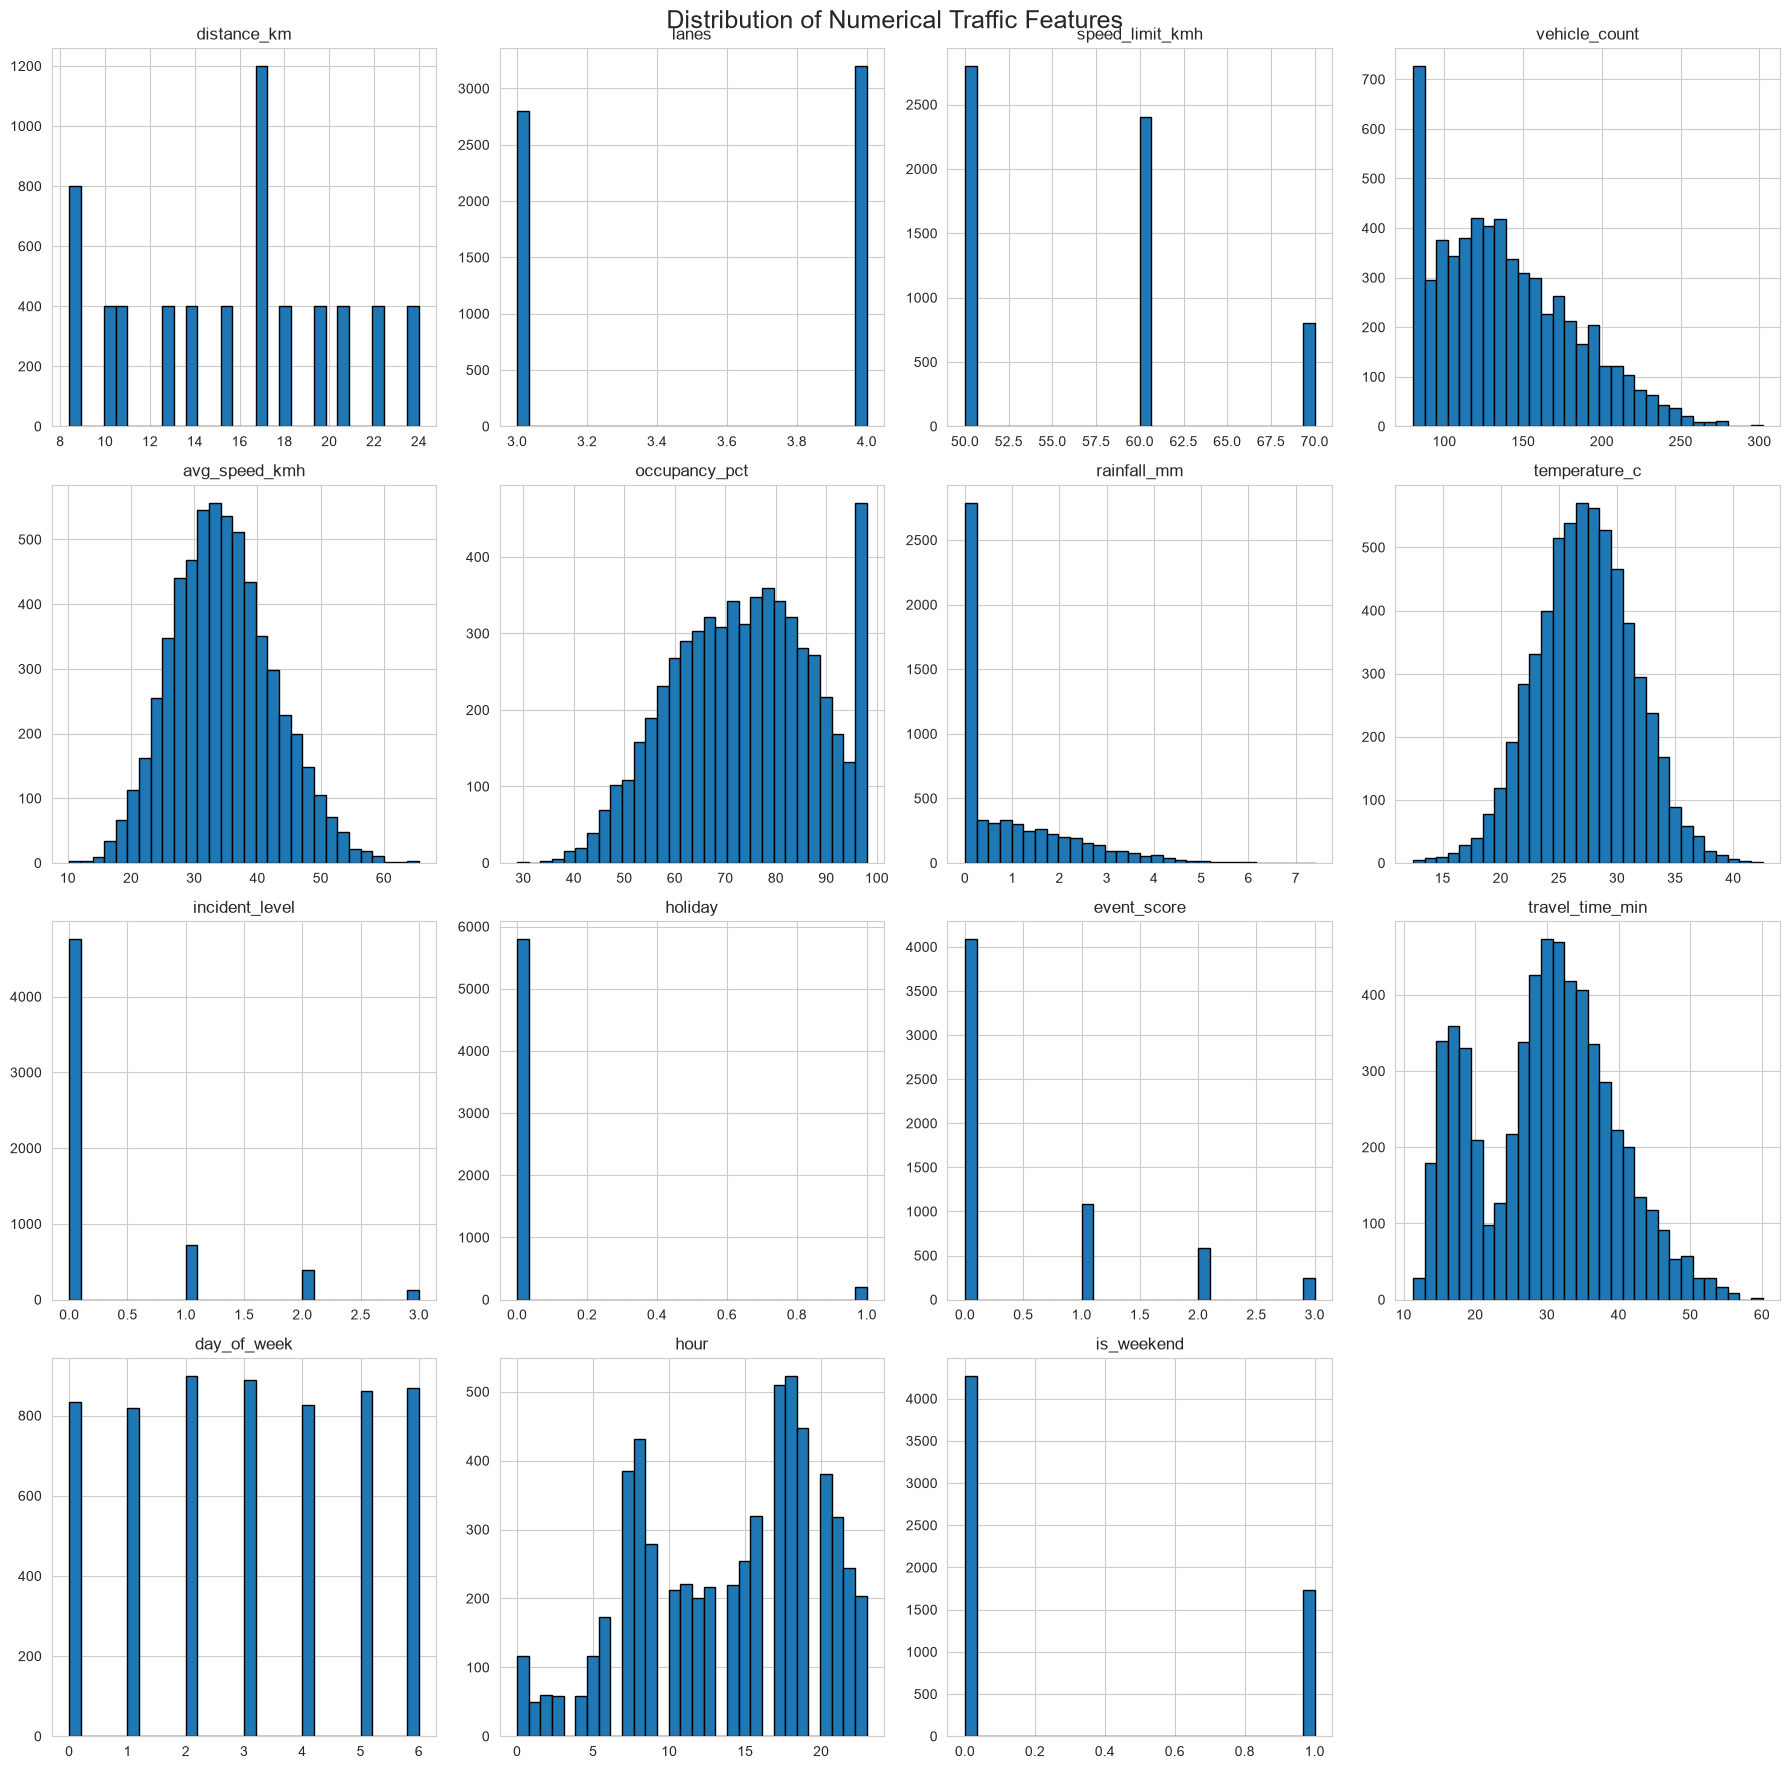

In [8]:
df[numerical_columns].hist(
    figsize=(18, 18),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Traffic Features", fontsize=18)
plt.tight_layout()
plt.show()


## 7. Boxplot Analysis

Boxplots are used to identify the spread of the data and potential outliers.

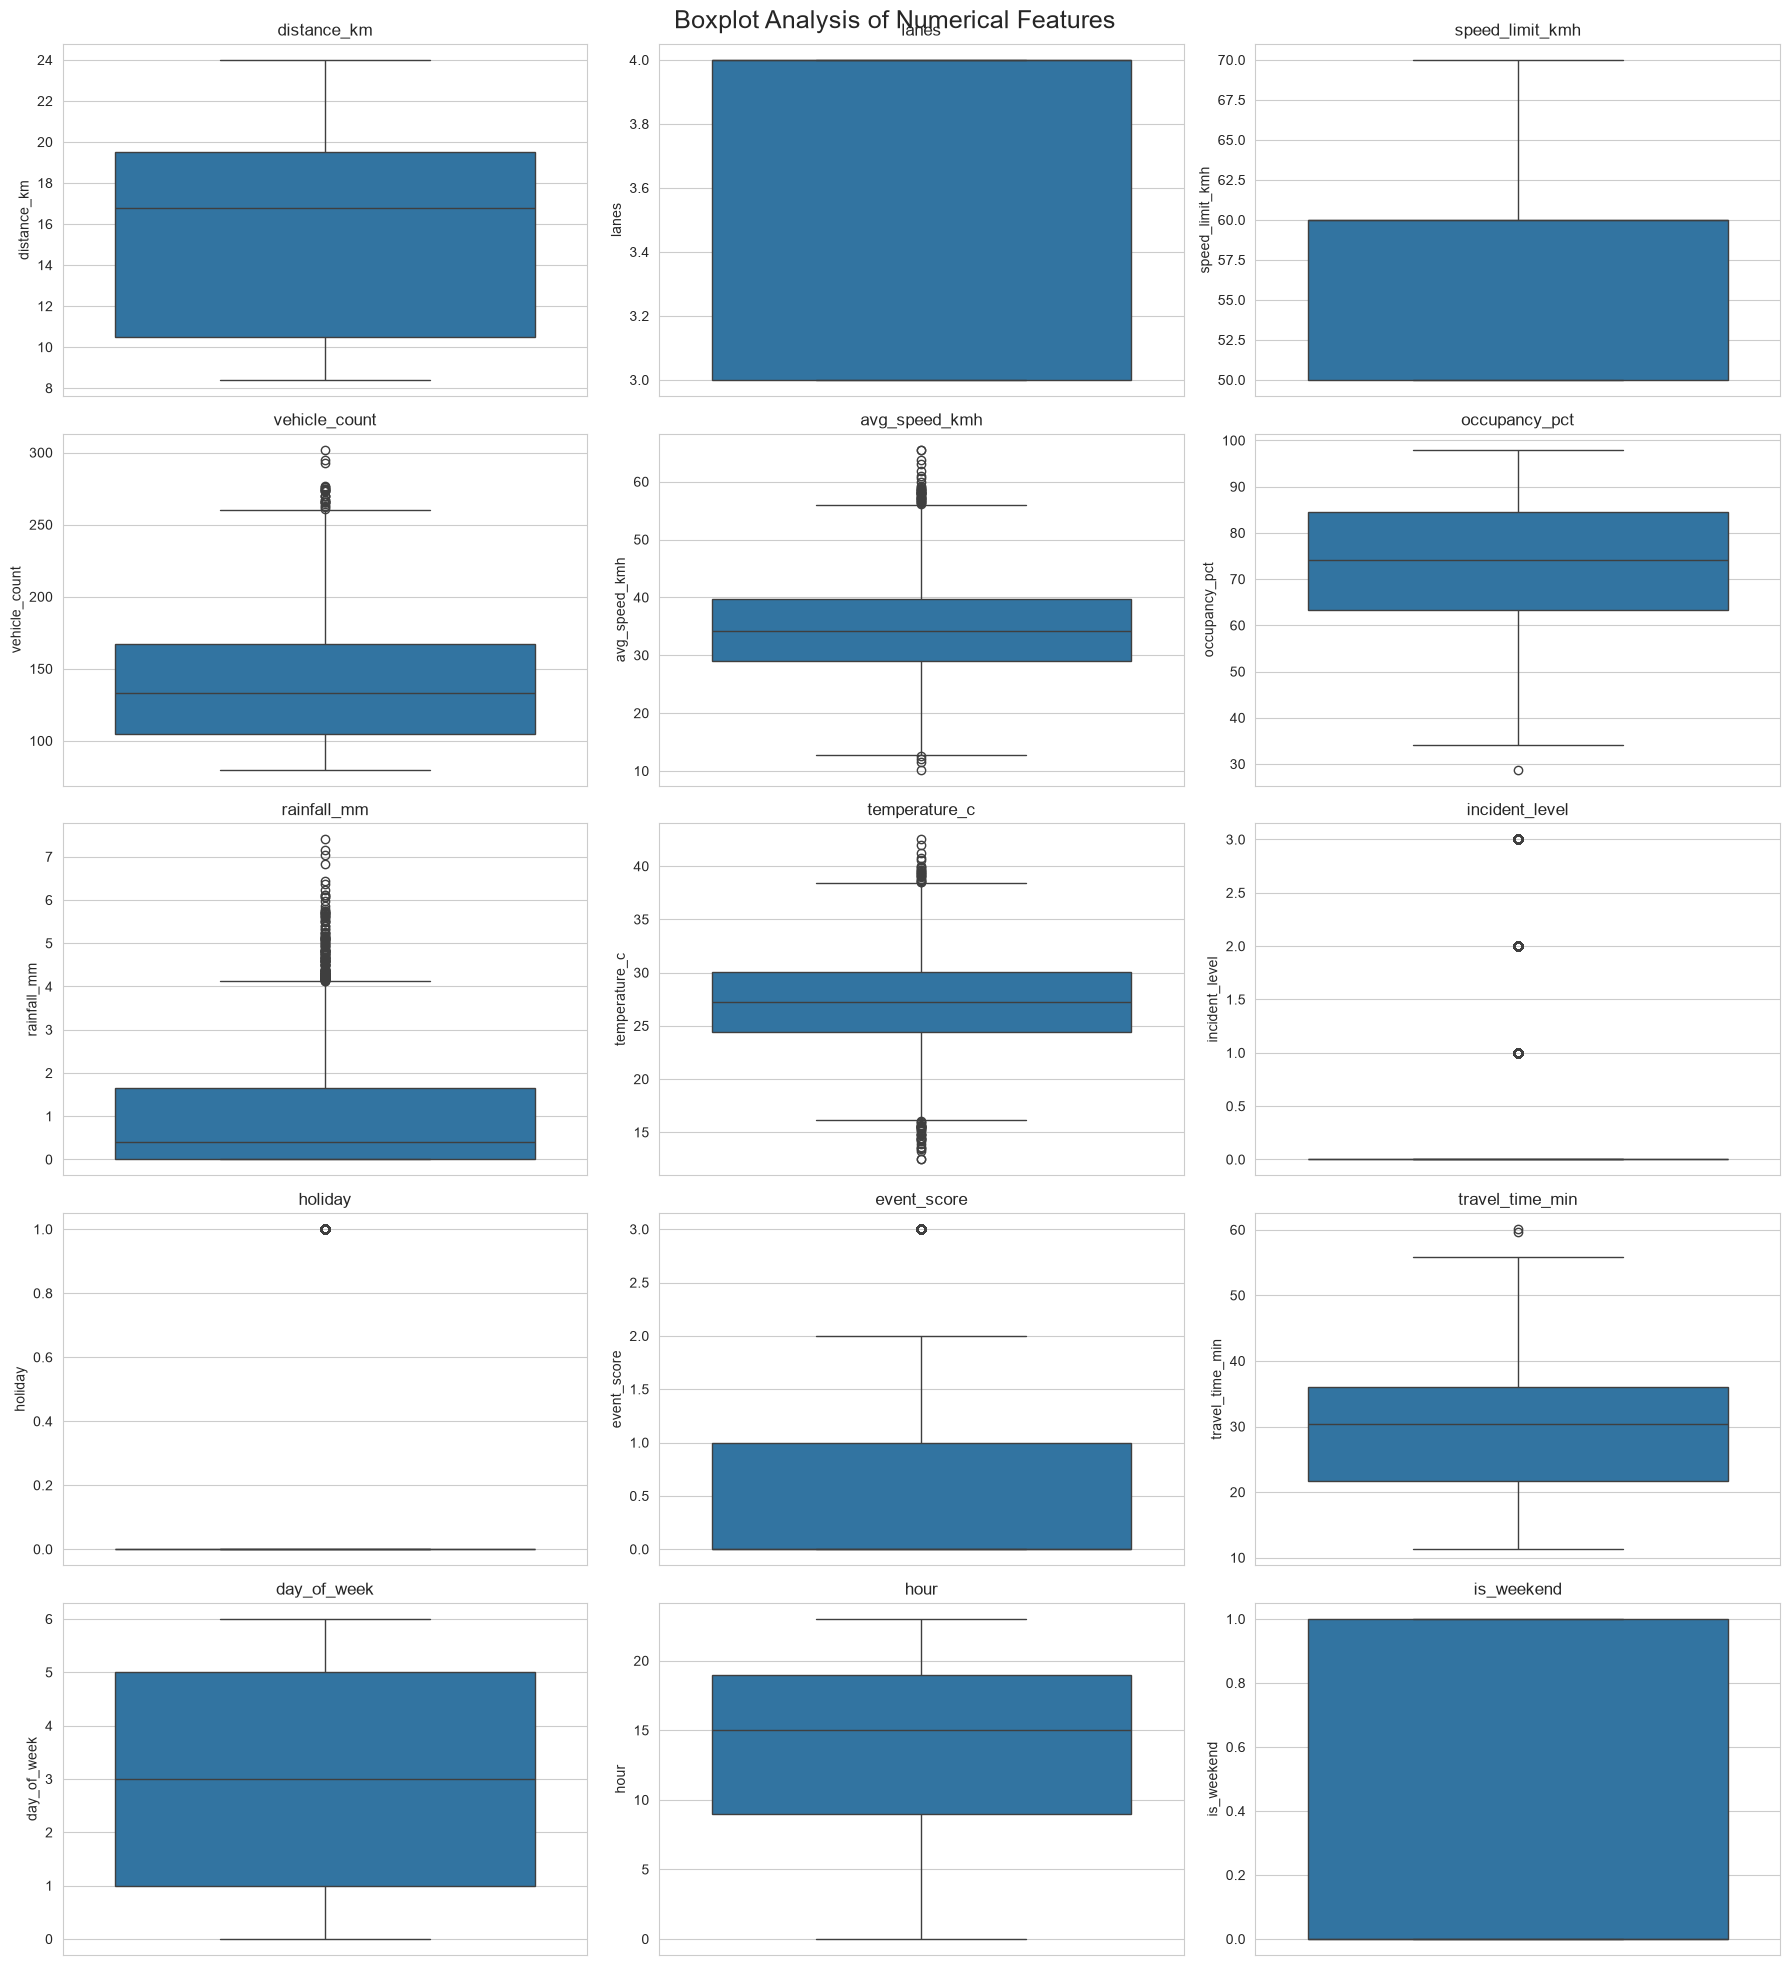

In [9]:
n = len(numerical_columns)
rows = int(np.ceil(n / 3))

fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = np.array(axes).reshape(-1)

for i, column in enumerate(numerical_columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(column)

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.suptitle("Boxplot Analysis of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()


## 8. Categorical Feature Analysis

Count plots show how observations are distributed across categorical variables.

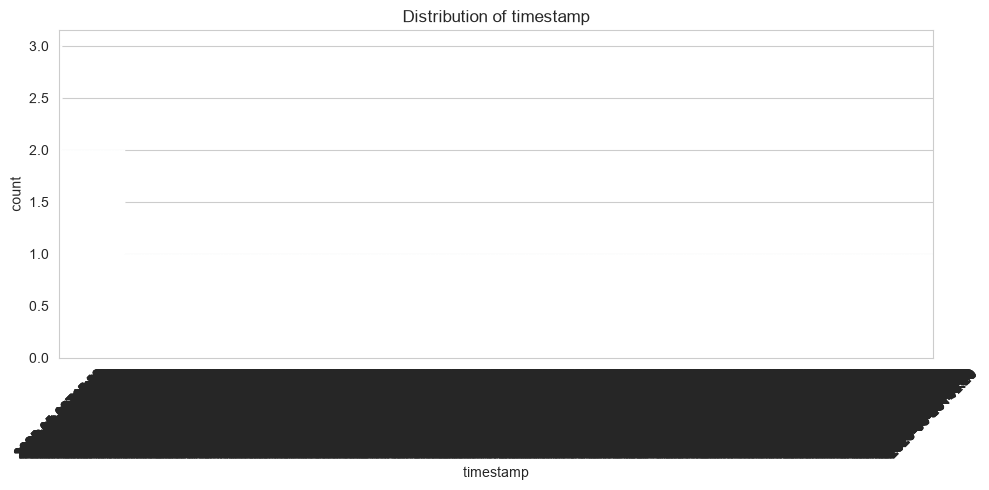

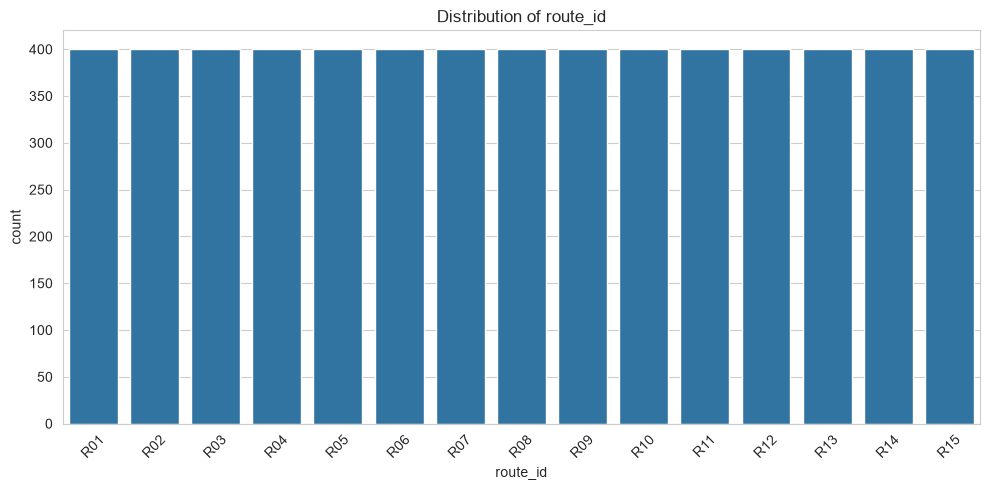

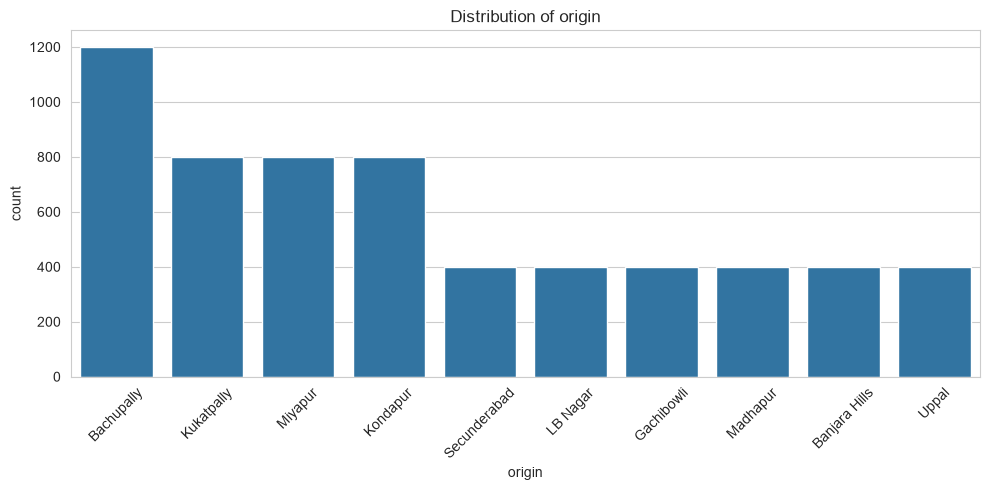

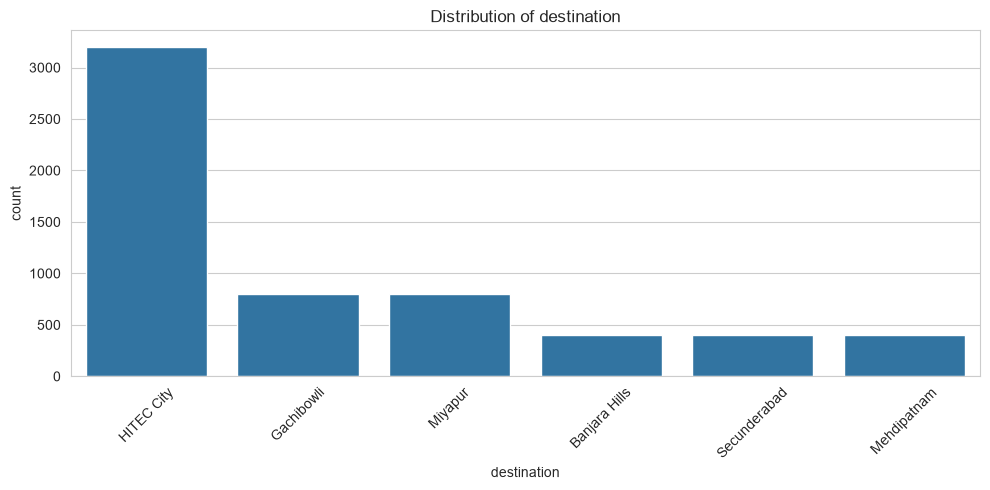

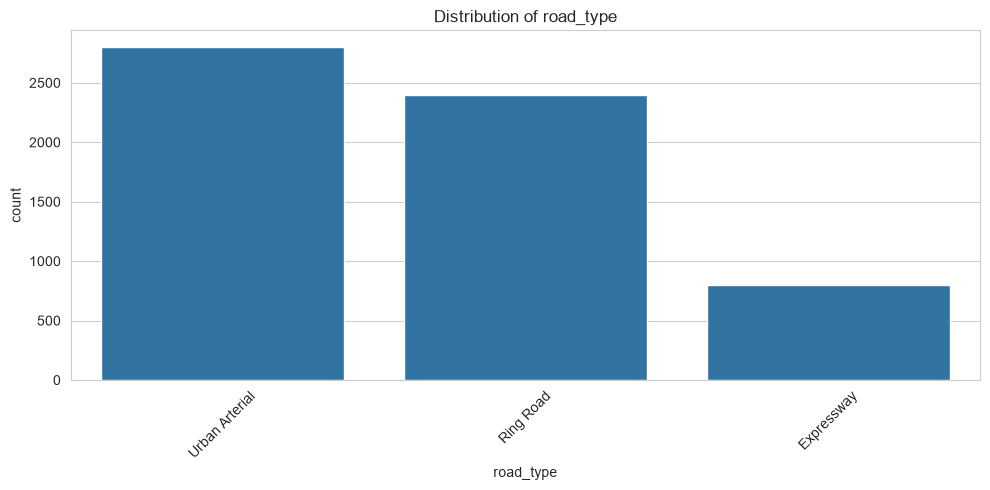

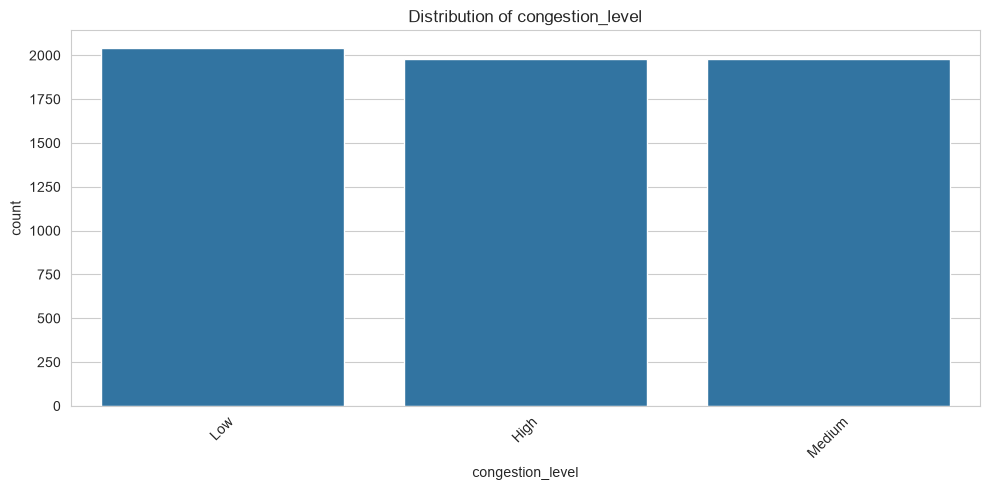

In [10]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, order=order)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Traffic Volume Analysis

Vehicle count is one of the most important indicators of traffic flow.

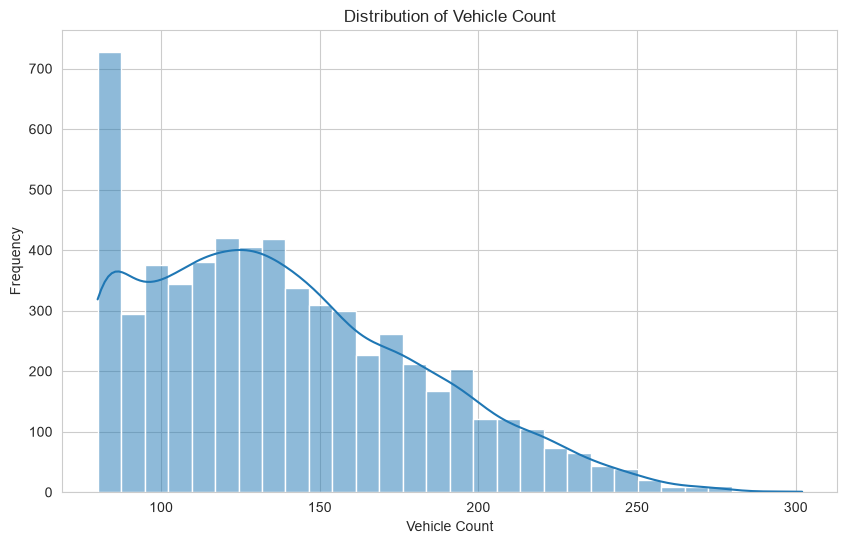

Vehicle count summary:
count    6000.000000
mean      138.675667
std        42.742718
min        80.000000
25%       105.000000
50%       133.000000
75%       167.000000
max       302.000000
Name: vehicle_count, dtype: float64


In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["vehicle_count"], bins=30, kde=True)
plt.title("Distribution of Vehicle Count")
plt.xlabel("Vehicle Count")
plt.ylabel("Frequency")
plt.show()

print("Vehicle count summary:")
print(df["vehicle_count"].describe())


## 10. Average Speed Analysis

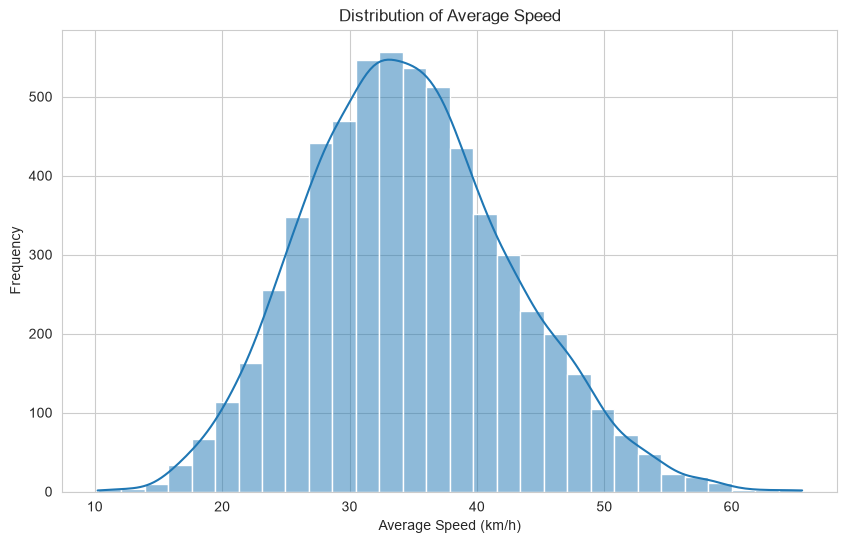

count    6000.000000
mean       34.628393
std         8.019668
min        10.220000
25%        28.940000
50%        34.160000
75%        39.772500
max        65.530000
Name: avg_speed_kmh, dtype: float64


In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df["avg_speed_kmh"], bins=30, kde=True)
plt.title("Distribution of Average Speed")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Frequency")
plt.show()

print(df["avg_speed_kmh"].describe())


## 11. Road Occupancy Analysis

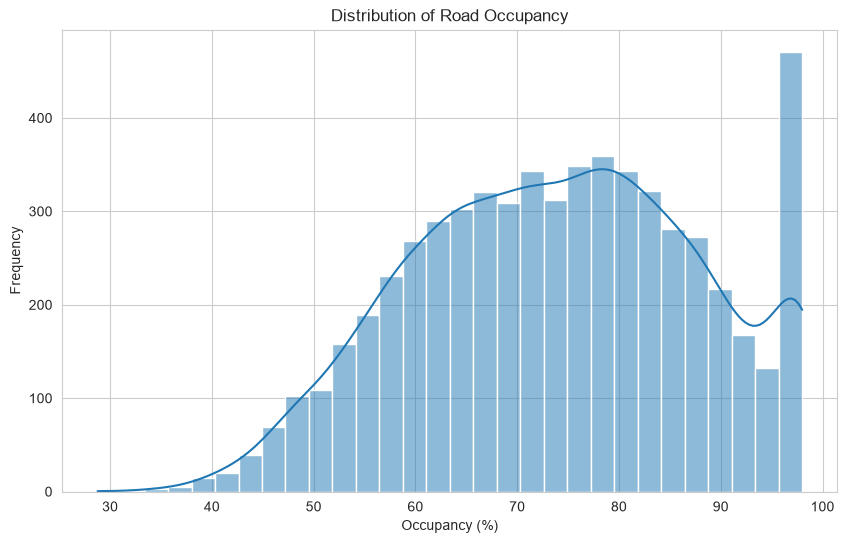

count    6000.000000
mean       73.926372
std        14.030948
min        28.770000
25%        63.400000
50%        74.120000
75%        84.502500
max        98.000000
Name: occupancy_pct, dtype: float64


In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df["occupancy_pct"], bins=30, kde=True)
plt.title("Distribution of Road Occupancy")
plt.xlabel("Occupancy (%)")
plt.ylabel("Frequency")
plt.show()

print(df["occupancy_pct"].describe())


## 12. Travel Time Analysis

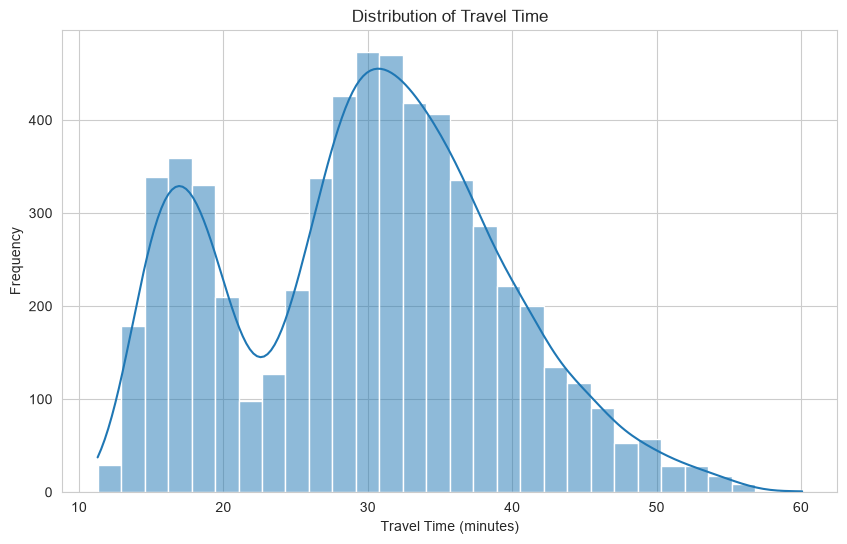

count    6000.000000
mean       29.772540
std         9.343206
min        11.290000
25%        21.765000
50%        30.340000
75%        36.100000
max        60.080000
Name: travel_time_min, dtype: float64


In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df["travel_time_min"], bins=30, kde=True)
plt.title("Distribution of Travel Time")
plt.xlabel("Travel Time (minutes)")
plt.ylabel("Frequency")
plt.show()

print(df["travel_time_min"].describe())


## 13. Traffic Pattern by Hour

Analyze how vehicle volume and speed change during different hours of the day.

In [15]:
hourly = df.groupby("hour").agg(
    average_vehicle_count=("vehicle_count", "mean"),
    average_speed=("avg_speed_kmh", "mean"),
    average_occupancy=("occupancy_pct", "mean"),
    average_travel_time=("travel_time_min", "mean")
).reset_index()

hourly


,hour,average_vehicle_count,average_speed,average_occupancy,average_travel_time
0,0,115.393162,38.381966,66.001197,28.047692
1,1,109.300000,39.264000,63.338600,28.158400
2,2,108.783333,37.308000,65.346167,30.498667
3,3,109.327586,38.040000,62.680517,28.513448
4,4,107.689655,37.008966,66.130690,28.357759
5,5,112.136752,38.084701,64.944615,27.244701
6,6,112.271676,37.715260,65.595260,28.967572
7,7,170.028571,31.652130,83.115818,31.806649
8,8,165.969907,31.046944,82.353472,31.017130
9,9,166.569892,32.201326,82.294839,30.460108


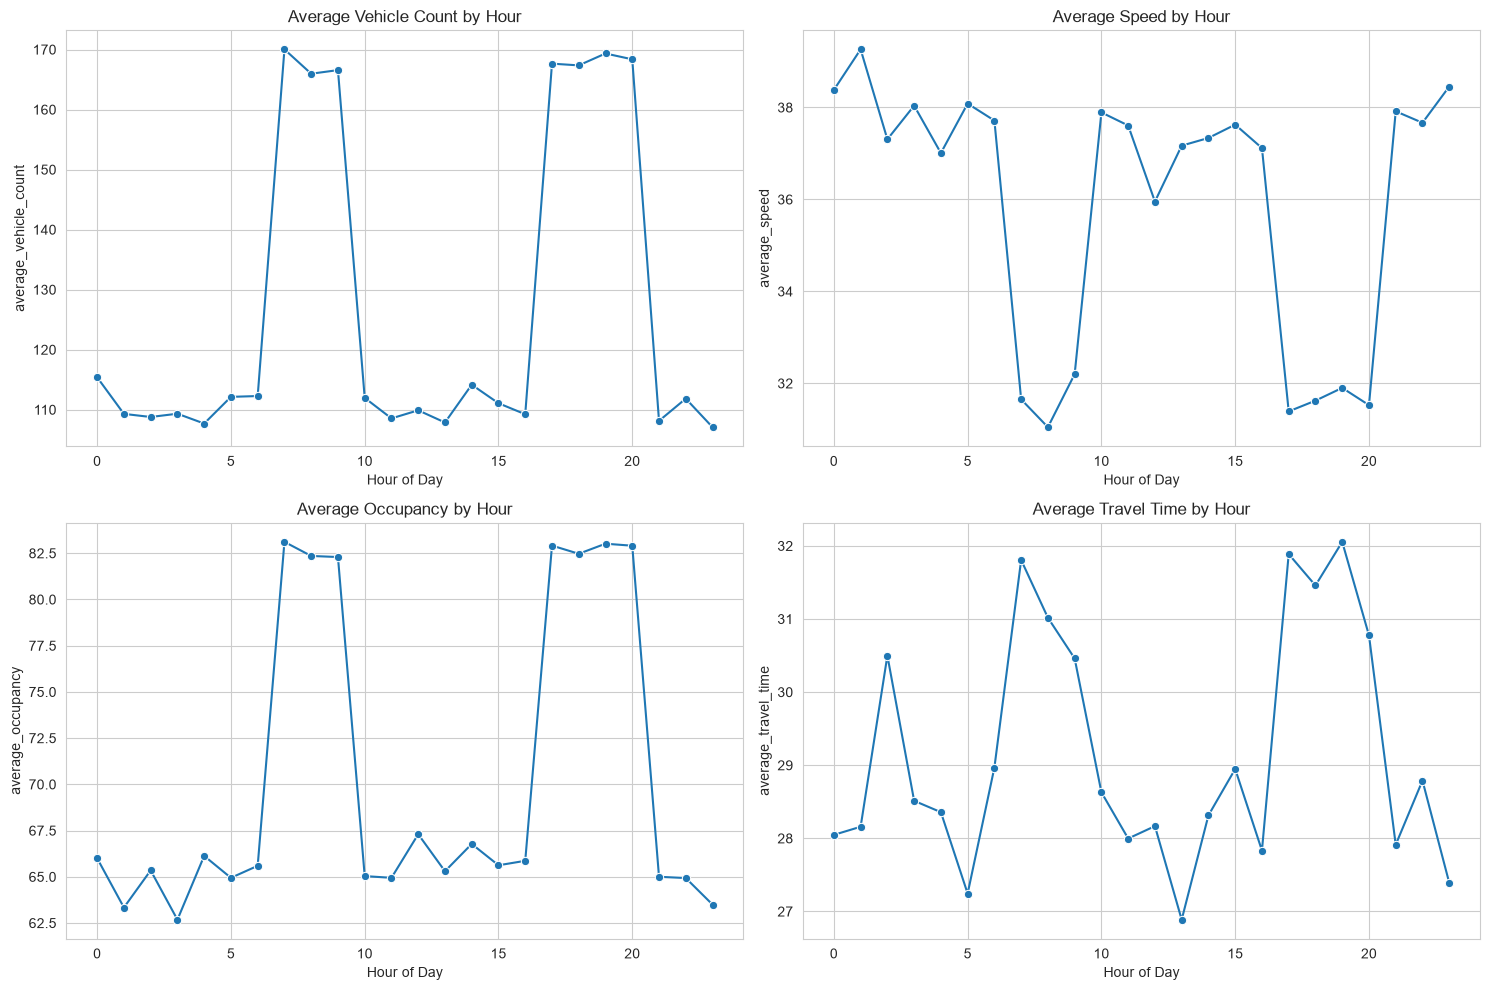

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=hourly, x="hour", y="average_vehicle_count", marker="o", ax=axes[0,0])
axes[0,0].set_title("Average Vehicle Count by Hour")

sns.lineplot(data=hourly, x="hour", y="average_speed", marker="o", ax=axes[0,1])
axes[0,1].set_title("Average Speed by Hour")

sns.lineplot(data=hourly, x="hour", y="average_occupancy", marker="o", ax=axes[1,0])
axes[1,0].set_title("Average Occupancy by Hour")

sns.lineplot(data=hourly, x="hour", y="average_travel_time", marker="o", ax=axes[1,1])
axes[1,1].set_title("Average Travel Time by Hour")

for ax in axes.flat:
    ax.set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()


## 14. Congestion Level Analysis

congestion_level
Low       2040
High      1980
Medium    1980
Name: count, dtype: int64


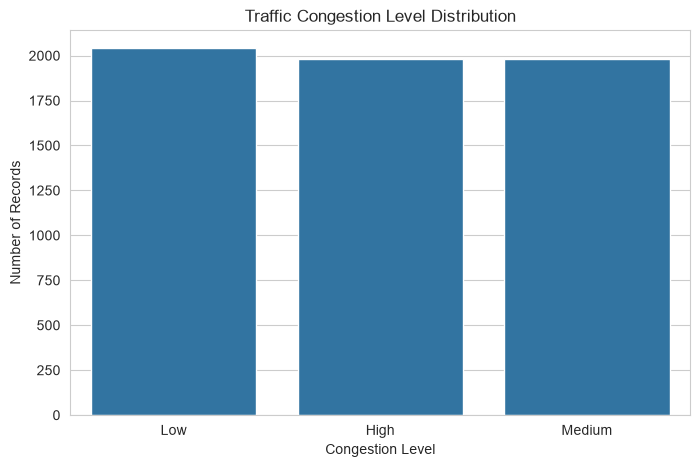

In [17]:
if "congestion_level" in df.columns:
    print(df["congestion_level"].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df,
        x="congestion_level",
        order=df["congestion_level"].value_counts().index
    )
    plt.title("Traffic Congestion Level Distribution")
    plt.xlabel("Congestion Level")
    plt.ylabel("Number of Records")
    plt.show()


In [18]:
if "congestion_level" in df.columns:
    congestion_summary = df.groupby("congestion_level")[[
        "vehicle_count",
        "avg_speed_kmh",
        "occupancy_pct",
        "travel_time_min"
    ]].mean().round(2)

    display(congestion_summary)


,vehicle_count,avg_speed_kmh,occupancy_pct,travel_time_min
congestion_level,,,,
High,164.64,27.67,88.49,34.04
Low,110.05,41.26,59.08,26.18
Medium,142.20,34.75,74.66,29.21


## 15. Relationship Between Traffic Variables

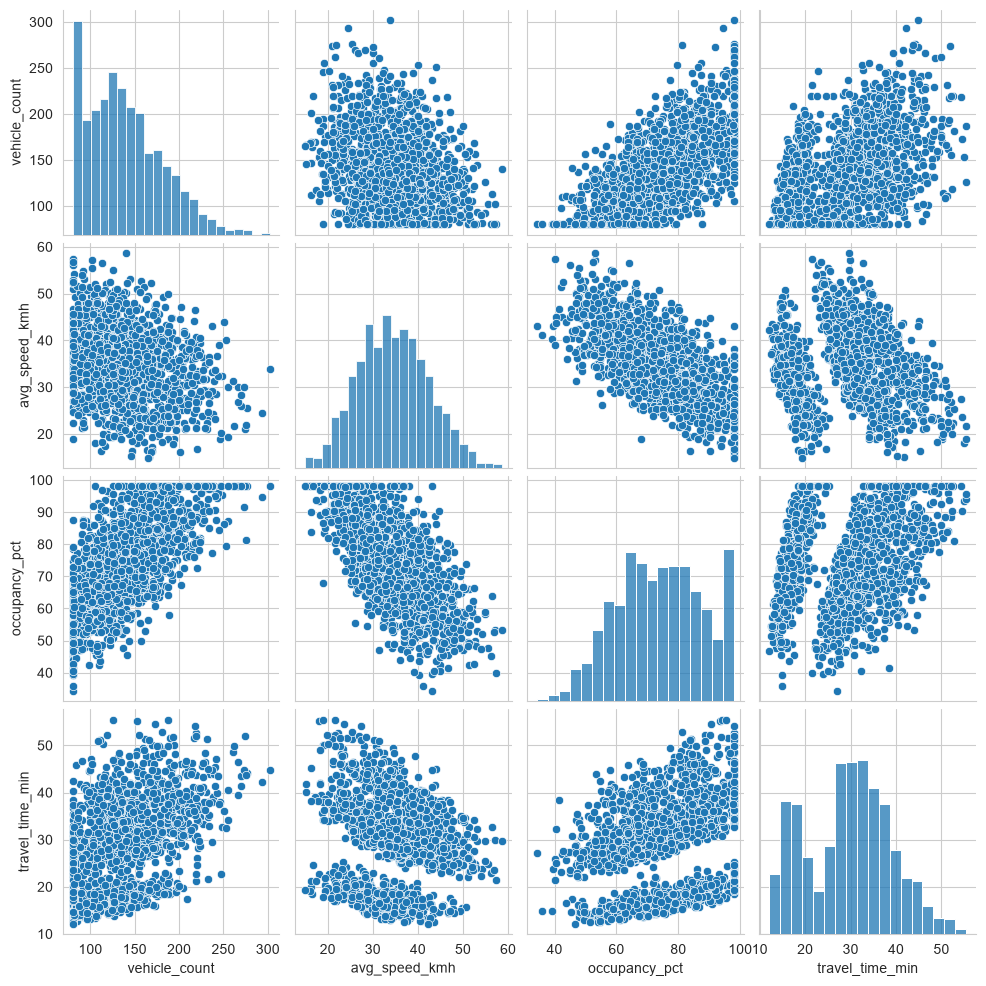

In [19]:
relationship_features = [
    "vehicle_count",
    "avg_speed_kmh",
    "occupancy_pct",
    "travel_time_min"
]

sns.pairplot(
    df[relationship_features].sample(
        min(1500, len(df)),
        random_state=42
    )
)
plt.show()


## 16. Correlation Analysis

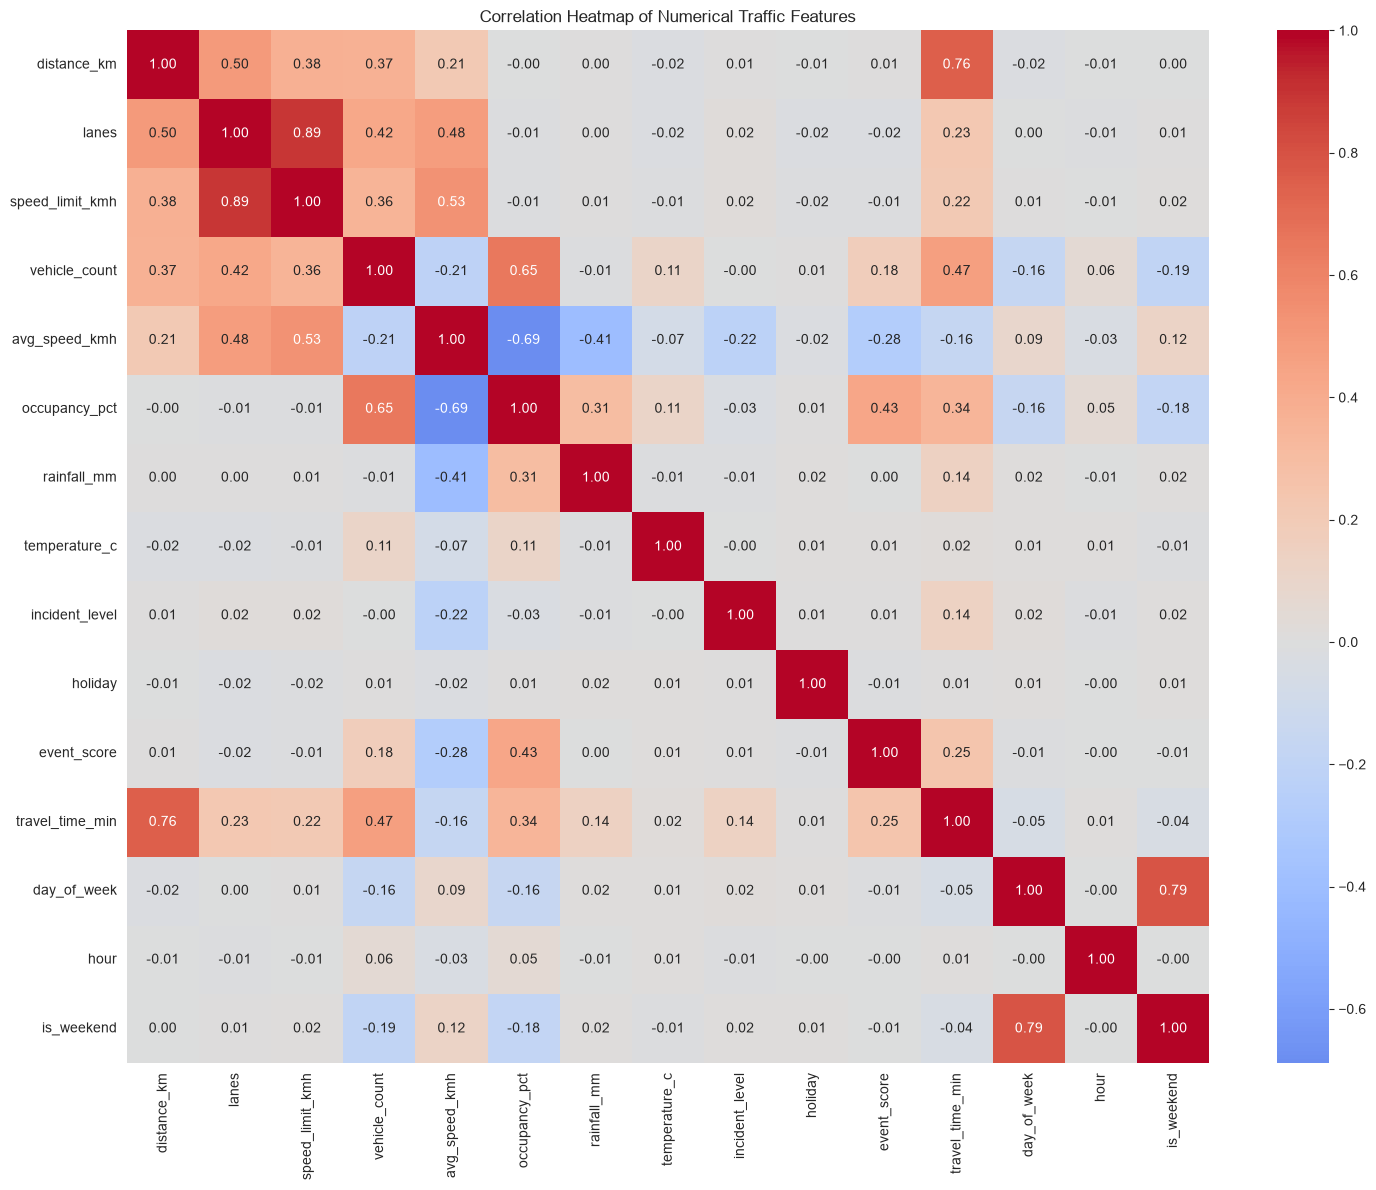

In [20]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Traffic Features")
plt.tight_layout()
plt.show()


## 17. Important Traffic Relationships

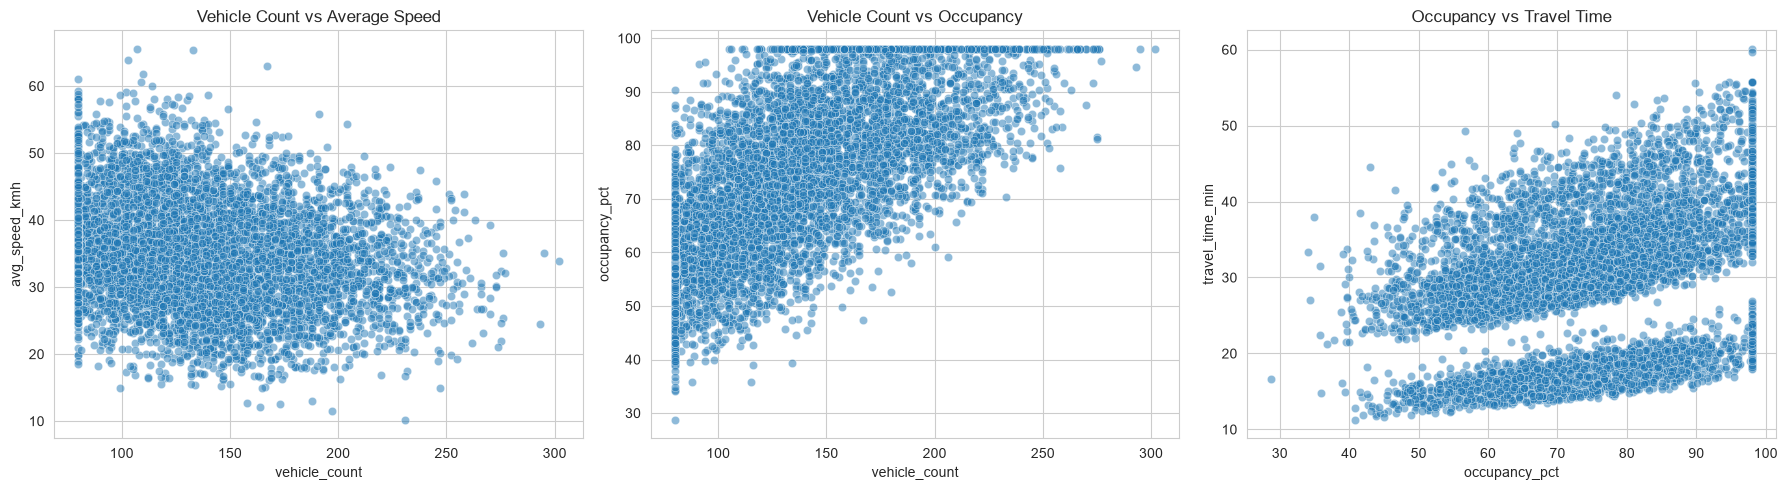

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x="vehicle_count",
    y="avg_speed_kmh",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Vehicle Count vs Average Speed")

sns.scatterplot(
    data=df,
    x="vehicle_count",
    y="occupancy_pct",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Vehicle Count vs Occupancy")

sns.scatterplot(
    data=df,
    x="occupancy_pct",
    y="travel_time_min",
    alpha=0.5,
    ax=axes[2]
)
axes[2].set_title("Occupancy vs Travel Time")

plt.tight_layout()
plt.show()


## 18. Weather and Event Analysis

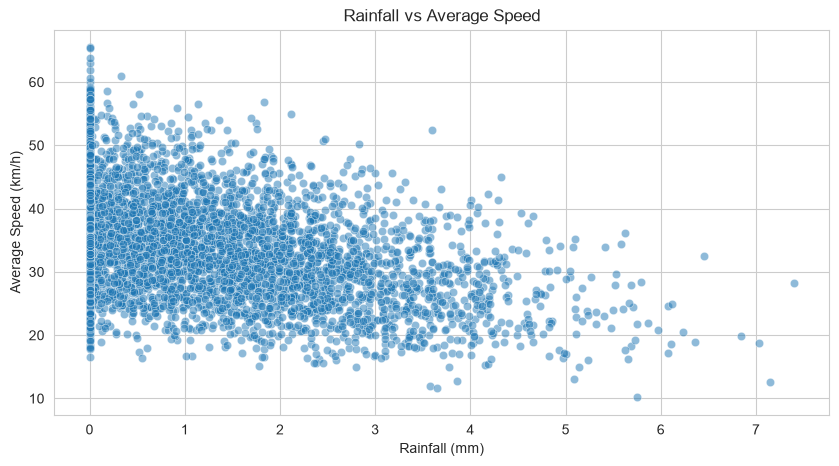

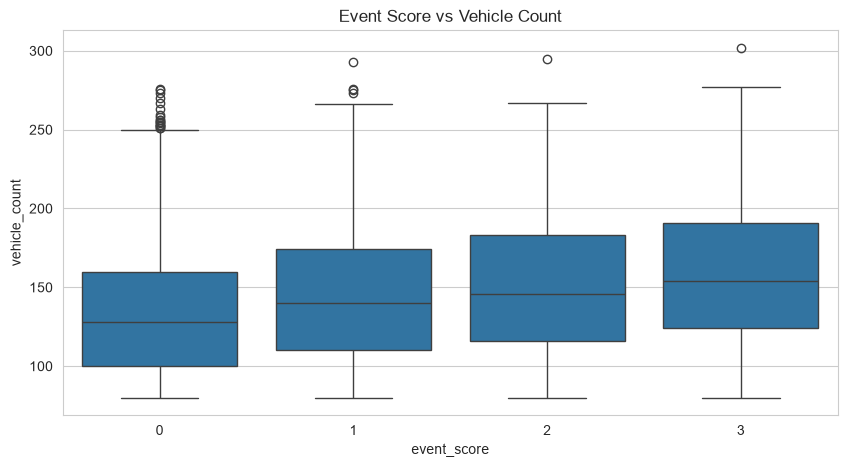

In [22]:
if "rainfall_mm" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=df,
        x="rainfall_mm",
        y="avg_speed_kmh",
        alpha=0.5
    )
    plt.title("Rainfall vs Average Speed")
    plt.xlabel("Rainfall (mm)")
    plt.ylabel("Average Speed (km/h)")
    plt.show()

if "event_score" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="event_score", y="vehicle_count")
    plt.title("Event Score vs Vehicle Count")
    plt.show()


## 19. Outlier Summary

The IQR method is used to count potential outliers in numerical traffic variables.

In [23]:
outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[column] < lower) | (df[column] > upper)).sum()

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": int(count),
        "Outlier %": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values("Potential Outliers", ascending=False)


,Feature,Lower Bound,Upper Bound,Potential Outliers,Outlier %
8,incident_level,0.00000,0.00000,1242,20.70
10,event_score,-1.50000,2.50000,247,4.12
9,holiday,0.00000,0.00000,204,3.40
6,rainfall_mm,-2.47500,4.12500,148,2.47
7,temperature_c,16.04125,38.49125,56,0.93
4,avg_speed_kmh,12.69125,56.02125,42,0.70
3,vehicle_count,12.00000,260.00000,26,0.43
11,travel_time_min,0.26250,57.60250,2,0.03
5,occupancy_pct,31.74625,116.15625,1,0.02
2,speed_limit_kmh,35.00000,75.00000,0,0.00


## 20. Key EDA Observations

Use the outputs and plots above to record the main observations from the dataset.

### Points to discuss
- Overall dataset size and structure.
- Whether missing values or duplicate rows are present.
- Which traffic variables show the widest variation.
- How vehicle volume changes during different hours.
- How average speed changes with traffic volume.
- The relationship between occupancy and travel time.
- Which congestion level occurs most frequently.
- Important positive or negative correlations.
- Features with noticeable potential outliers.
- Whether weather or event conditions appear associated with traffic changes.

## 21. Conclusion

The exploratory analysis provides an overall understanding of the traffic-flow dataset through statistical summaries, distributions, categorical analysis, time-based analysis, relationship plots, correlation analysis, and outlier detection.

The findings from this EDA can be used as the foundation for a later traffic-pattern modeling or clustering project, but **no machine-learning model is performed in this notebook**.
